# Naive OLS 2

Fixed model:

- Regressand mode: `cpi_on_xi_x_oil_and_c_diff`
- Regressors: `xi_x_oil`, `c_diff`, CPI lags, optional country FE
- CPI outliers are removed before estimation using IQR fences on `cpi_pct_change`


In [29]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from io_networks import regression


In [30]:
ROOT = Path.cwd().resolve().parent

xi_path = ROOT / "data/processed/xi/regular/xi_by_country_year.parquet"
c_path = ROOT / "data/processed/c/regular/c_by_country_year.parquet"
c_diff_path = ROOT / "data/processed/c_diff/regular/c_diff_by_country_year.parquet"
cpi_path = ROOT / "data/processed/cpi/annual_cpi.csv"
oil_path = ROOT / "data/processed/oil/annual_oil.csv"

# Minimal controls
cpi_lags = 1
include_country_fe = False
include_time_fe = False

print("cpi_lags:", cpi_lags)
print("include_country_fe:", include_country_fe)
print("include_time_fe:", include_time_fe)


cpi_lags: 1
include_country_fe: False
include_time_fe: False


In [31]:
xi_df = regression.load_xi(xi_path)
c_df = regression.load_c(c_path)
c_diff_df = regression.load_c_diff(c_diff_path)
cpi_df = regression.load_cpi_pct_change(cpi_path, freq="A")
oil_df = regression.load_oil_pct_change(oil_path, freq="A")

reg_df = regression.prepare_regression_df(xi_df, c_df, cpi_df, oil_df, c_diff_df=c_diff_df)

print("Rows before CPI outlier filter:", len(reg_df))
print("Countries before filter:", reg_df["country"].nunique())
print("Years before filter:", int(reg_df["year"].min()), "-", int(reg_df["year"].max()))


Rows before CPI outlier filter: 2116
Countries before filter: 80
Years before filter: 1996 - 2022


In [32]:
# Remove CPI outliers using IQR fences.
q1 = reg_df["cpi_pct_change"].quantile(0.25)
q3 = reg_df["cpi_pct_change"].quantile(0.75)
iqr = q3 - q1
lower = q1 - 5 * iqr
upper = q3 + 5 * iqr

reg_df_model = reg_df.loc[reg_df["cpi_pct_change"].between(lower, upper)].copy()

print(f"CPI IQR fence: [{lower:.6f}, {upper:.6f}]")
print("Rows after CPI outlier filter:", len(reg_df_model))
print("Dropped rows:", len(reg_df) - len(reg_df_model))


CPI IQR fence: [-0.219748, 0.295615]
Rows after CPI outlier filter: 2052
Dropped rows: 64


In [33]:
work = reg_df_model[["country", "year", "xi_x_oil", "c_diff", "cpi_pct_change"]].copy()
work = work.sort_values(["country", "year"]).reset_index(drop=True)

lag_cols = []
for lag in range(1, cpi_lags + 1):
    col = f"cpi_pct_change_lag{lag}"
    work[col] = work.groupby("country")["cpi_pct_change"].shift(lag)
    lag_cols.append(col)

x_cols = ["xi_x_oil", "c_diff"] + lag_cols
x_base = work[x_cols].copy()

if include_country_fe:
    fe_country = pd.get_dummies(work["country"], prefix="country_fe", drop_first=True, dtype=float)
    x_base = pd.concat([x_base, fe_country], axis=1)

if include_time_fe:
    fe_time = pd.get_dummies(work["year"], prefix="year_fe", drop_first=True, dtype=float)
    x_base = pd.concat([x_base, fe_time], axis=1)

design = pd.concat([work[["cpi_pct_change"]], x_base], axis=1).dropna().reset_index(drop=True)
if design.empty:
    raise ValueError("No rows left for OLS after lagging/dropna. Reduce lags or inspect missing data.")

y = design["cpi_pct_change"]
x = regression.sm.add_constant(design.drop(columns=["cpi_pct_change"]), has_constant="add")
model = regression.sm.OLS(y, x, missing="raise").fit(cov_type="HC3")

ci = model.conf_int()
coef_df = pd.DataFrame(
    {
        "term": model.params.index,
        "coef": model.params.values,
        "std_err_hc3": model.bse.values,
        "t": model.tvalues.values,
        "p_value": model.pvalues.values,
        "ci_low_95": ci.iloc[:, 0].values,
        "ci_high_95": ci.iloc[:, 1].values,
    }
)

coef_df


,term,coef,std_err_hc3,t,p_value,ci_low_95,ci_high_95
0,const,0.010947,0.001010,10.842763,2.158523e-27,0.008968,0.012925
1,xi_x_oil,0.729043,0.078135,9.330524,1.053488e-20,0.575901,0.882186
2,c_diff,-0.034078,0.013303,-2.561766,1.041414e-02,-0.060151,-0.008006
3,cpi_pct_change_lag1,0.711184,0.030810,23.083045,6.853801e-118,0.650798,0.771570


In [34]:
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:         cpi_pct_change   R-squared:                       0.549
Model:                            OLS   Adj. R-squared:                  0.549
Method:                 Least Squares   F-statistic:                     200.1
Date:                Sun, 15 Feb 2026   Prob (F-statistic):          2.78e-113
Time:                        19:08:42   Log-Likelihood:                 4156.5
No. Observations:                1973   AIC:                            -8305.
Df Residuals:                    1969   BIC:                            -8283.
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   0.0109    

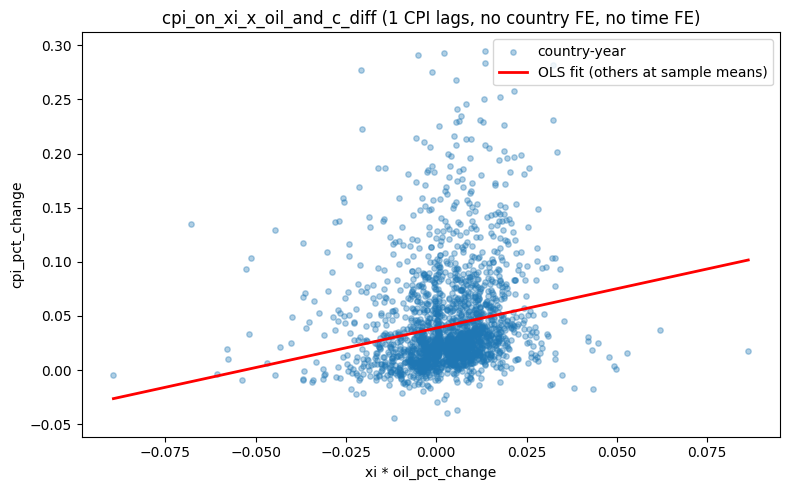

In [35]:
x = reg_df_model["xi_x_oil"].to_numpy(dtype=float)
y = reg_df_model["cpi_pct_change"].to_numpy(dtype=float)

plt.figure(figsize=(8, 5))
plt.scatter(x, y, alpha=0.35, s=15, label="country-year")

x_line = np.linspace(np.nanmin(x), np.nanmax(x), 100)
y_line = model.params["const"] + model.params["xi_x_oil"] * x_line

for lag in range(1, cpi_lags + 1):
    term = f"cpi_pct_change_lag{lag}"
    if term in model.params.index:
        lag_mean = (
            reg_df_model.sort_values(["country", "year"])
            .groupby("country")["cpi_pct_change"]
            .shift(lag)
            .mean()
        )
        y_line += model.params[term] * lag_mean

if "c_diff" in model.params.index:
    y_line += model.params["c_diff"] * reg_df_model["c_diff"].mean()

plt.plot(x_line, y_line, color="red", linewidth=2, label="OLS fit (others at sample means)")
plt.xlabel("xi * oil_pct_change")
plt.ylabel("cpi_pct_change")
country_fe_label = "country FE" if include_country_fe else "no country FE"
time_fe_label = "time FE" if include_time_fe else "no time FE"
plt.title(f"cpi_on_xi_x_oil_and_c_diff ({cpi_lags} CPI lags, {country_fe_label}, {time_fe_label})")
plt.legend()
plt.tight_layout()
plt.show()
